In [2]:
import pandas as pd
import numpy as np
import re
from cleantext import clean
import torch
from transformers import TrainingArguments, Trainer, pipeline
from transformers import XLNetTokenizer, XLNetForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import evaluate
from datasets import Dataset, DatasetDict
import numpy as np
from transformers import TrainingArguments
from transformers import Trainer
from transformers import pipeline
import matplotlib.pyplot as plt

In [3]:
test_data=pd.read_csv("./emotion-labels-test.csv")
train_data=pd.read_csv("./emotion-labels-train.csv")
val_data=pd.read_csv("./emotion-labels-val.csv")

data=pd.concat([test_data, train_data, val_data])


data.head()

,text,label
0,You must be knowing #blithe means (adj.) Happ...,joy
1,Old saying 'A #smile shared is one gained for ...,joy
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy
3,@Elaminova sparkling water makes your life spa...,joy
4,I'm tired of everybody telling me to chill out...,joy


<>:3: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:3: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
C:\Users\faiz5\AppData\Local\Temp\ipykernel_13976\255725388.py:3: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  data["clean-text"]=data["clean-text"].apply(lambda x: re.sub('[^\w\s]',' ',x))


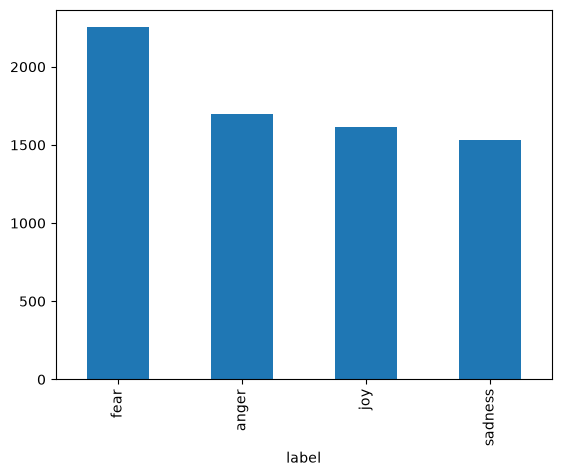

In [4]:
data["clean-text"]=data["text"].apply(lambda x: clean(x))

data["clean-text"]=data["clean-text"].apply(lambda x: re.sub('[^\w\s]',' ',x))

data["label"].value_counts().plot(kind="bar")
plt.show()

In [5]:
print(data.columns.tolist())
data


['text', 'label', 'clean-text']


,text,label,clean-text
0,You must be knowing #blithe means (adj.) Happ...,joy,must know blith mean adj happi cheer
1,Old saying 'A #smile shared is one gained for ...,joy,old say smile share one gain anoth day yeglif ...
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy,bridget jone babi bloodi hilari bridgetjones...
3,@Elaminova sparkling water makes your life spa...,joy,elaminova sparkl water make life sparkli
4,I'm tired of everybody telling me to chill out...,joy,im tire everybodi tell chill everyth ok fuck i...
...,...,...,...
342,Common app just randomly logged me out as I wa...,sadness,common app randomli log write last part colleg...
343,"I'd rather laugh with the rarest genius, in be...",sadness,id rather laugh rarest geniu beauti allianc ke...
344,If you #invest in my new #film I will stop ask...,sadness,invest new film stop ask invest new film conce...
345,"Just watched Django Unchained, Other people ma...",sadness,watch django unchain peopl may frown titter de...


['text', 'label', 'clean-text']
label
joy        1533
fear       1533
anger      1533
sadness    1533
Name: count, dtype: int64


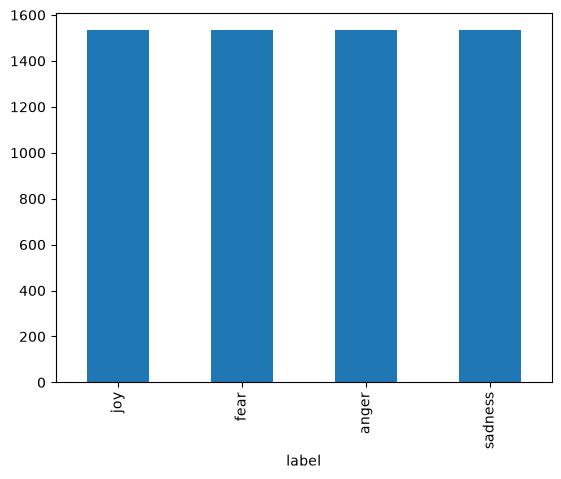

In [6]:
min_label = data["label"].value_counts().min()

balanced_parts = []

for label in data["label"].unique():
    part = data[data["label"] == label].sample(n=min_label, random_state=42)
    balanced_parts.append(part)

data = pd.concat(balanced_parts, ignore_index=True)

print(data.columns.tolist())
print(data["label"].value_counts())

data["label"].value_counts().plot(kind="bar")
plt.show()

In [7]:
encode=LabelEncoder()

data["label-int"]=encode.fit_transform(data["label"])

data.head()

,text,label,clean-text,label-int
0,Could not be happier!!,joy,could happier,2
1,Three days off a month with two ex wives and n...,joy,three day month two ex wive home could wors do...,2
2,"Good night, Twitter world! Wish you all good s...",joy,good night twitter world wish good sleep produ...,2
3,You know what's great about #GBBO ? Contestant...,joy,know what great gbbo contest help cheer import,2
4,@Myahrissavietta I'm cheery now 😘😉,joy,myahrissavietta im cheeri,2


In [8]:

train_data,test_data=train_test_split(data, test_size=0.2, random_state=42)
train_data, val_data=train_test_split(train_data, test_size=0.1, random_state=42)


print(len(train_data)) 
print(len(test_data))
print(len(val_data))

4414
1227
491


In [9]:
train_df=pd.DataFrame({"text" : train_data["clean-text"], "label" : train_data["label-int"]})
test_df=pd.DataFrame({"text" : test_data["clean-text"], "label" : test_data["label-int"]})
val_df=pd.DataFrame({"text" : val_data["clean-text"], "label" : val_data["label-int"]})

In [10]:


train_dataset=Dataset.from_dict(train_df)
test_dataset=Dataset.from_dict(test_df)
val_dataset=Dataset.from_dict(val_df)

final_dict=DatasetDict({'train': train_dataset,'test' : test_dataset, 'validation': val_dataset})
final_dict


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1227
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 491
    })
})

In [11]:
tokenizer=XLNetTokenizer.from_pretrained("xlnet-base-cased")


def tokenization_function(example):
    return tokenizer(
        example["text"], padding='max_length',truncation=True, max_length=128)
    

tokenizer_set=final_dict.map(tokenization_function, batched=True)

sample_text=tokenizer_set["train"][0]["text"]
sample_text


Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

Map:   0%|          | 0/491 [00:00<?, ? examples/s]

'sad even clear harvey cage belong final goodby littl man depress'

In [12]:
print(tokenizer_set["train"][0]["input_ids"])
print(tokenizer_set["train"][0]["label"])
print(tokenizer_set["train"][0]["attention_mask"])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5694, 176, 791, 17, 3327, 11470, 11275, 7893, 484, 195, 1164, 6007, 46, 368, 326, 28761, 4, 3]
3
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [13]:
small_train_dataset=tokenizer_set["train"].shuffle(seed=42).select(range(100))
small_eval_dataset=tokenizer_set["test"].shuffle(seed=42).select(range(100))

print(small_train_dataset)
print(small_eval_dataset)

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 100
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 100
})


In [14]:
model=XLNetForSequenceClassification.from_pretrained("xlnet-base-cased",
                                                        num_labels=4,
                                                        id2label={0:"fear",1:"anger",
                                                                  2:"joy",3:"sadness"},
                                                    label2id={"fear": 0, "anger": 1, "joy": 2, "sadness": 3})

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.weight              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
metric=evaluate.load("accuracy")
metric

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

EvaluationModule(name: "accuracy", module_type: "metric", features: {'predictions': Value('int32'), 'references': Value('int32')}, usage: """
Args:
    predictions (`list` of `int`): Predicted labels.
    references (`list` of `int`): Ground truth labels.
    normalize (`boolean`): If set to False, returns the number of correctly classified samples. Otherwise, returns the fraction of correctly classified samples. Defaults to True.
    sample_weight (`list` of `float`): Sample weights Defaults to None.

Returns:
    accuracy (`float` or `int`): Accuracy score. Minimum possible value is 0. Maximum possible value is 1.0, or the number of examples input, if `normalize` is set to `True`.. A higher score means higher accuracy.

Examples:

    Example 1-A simple example
        >>> accuracy_metric = evaluate.load("accuracy")
        >>> results = accuracy_metric.compute(references=[0, 1, 2, 0, 1, 2], predictions=[0, 1, 1, 2, 1, 0])
        >>> print(results)
        {'accuracy': 0.5}

    Exa

In [16]:
def compute_pred(eval_pred):
    logits,labels=eval_pred
    predictions=np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [17]:
trainee=TrainingArguments(output_dir="./fresh_xlnet_base_model",
                          eval_strategy="epoch",
                          num_train_epochs=3)


In [18]:
trainer=Trainer(
    model=model,
    args=trainee,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_pred)

trainer.train()

trainer.evaluate()

model.save_pretrained("my_finetuned_model", safe_serialization=False)


fine_tuned_model=XLNetForSequenceClassification.from_pretrained("my_finetuned_model")


c:\Users\faiz5\emotion classifier\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.591802,0.270000
2,No log,1.396420,0.200000
3,No log,1.419847,0.200000


c:\Users\faiz5\emotion classifier\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\faiz5\emotion classifier\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\faiz5\emotion classifier\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\faiz5\emotion classifier\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


c:\Users\faiz5\emotion classifier\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\faiz5\.cache\huggingface\hub\models--xlnet-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Training Loss,Validation Loss,Epoch,Accuracy
No log,1.419847,3,0.200000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

In [19]:
clf=pipeline(task="text-classification",
    model=fine_tuned_model,
    tokenizer=tokenizer    ) 

clf("This is a random test sentence", top_k=None)



[{'label': 'sadness', 'score': 0.27665242552757263},
 {'label': 'fear', 'score': 0.2702374756336212},
 {'label': 'joy', 'score': 0.23080164194107056},
 {'label': 'anger', 'score': 0.2223084717988968}]